# MarketScout: Система прогнозування цін на авто
Цей ноутбук призначений для побудови моделі машинного навчання, яка прогнозує вартість автомобілів на основі їхніх характеристик.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.base import BaseEstimator, RegressorMixin
from catboost import CatBoostRegressor, Pool
import joblib

RANDOM_SEED = 42
CURRENT_YEAR = 2026
N_FOLDS = 5  # кількість фолдів для Cross-Validation


In [23]:
data = pd.read_csv("../data/cars_dataset.csv")
df = data.copy()

print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")
print(f"Пропуски:\n{df.isnull().sum()}")
display(df.head(3))

Розмір датасету: 18893 рядків, 9 колонок
Пропуски:
ID             0
Mark          88
Model        854
Year           0
Price_USD      0
Mileage        0
Engine         0
Fuel           0
Gearbox        0
dtype: int64


,ID,Mark,Model,Year,Price_USD,Mileage,Engine,Fuel,Gearbox
0,2059468,Opel,Omega,1990,1900,300,0,"Бензин, 1.8 л.",Ручна / Механіка
1,39346065,Mercedes-Benz,eVito,2021,27800,257,0,Електро,Автомат
2,38511410,Volkswagen,E-Tharu,2020,18000,31,0,Електро,Автомат


## Очищення та підготовка даних

In [24]:
df = df.drop(columns=['ID', 'Engine'], errors='ignore')
df = df[df['Price_USD'] > 0].copy()
print(f"Після базового очищення: {len(df)} рядків")

Після базового очищення: 18617 рядків


In [25]:
df['Age'] = CURRENT_YEAR - df['Year']

df = df[(df['Age'] >= 0) & (df['Age'] <= 46)].copy()  # Відкидаємо авто до 1980 року
print(f"Після фільтрації за віком: {len(df)} рядків")

Після фільтрації за віком: 18551 рядків


In [26]:
# Розбиття Fuel на Fuel_Type та Engine_Capacity
split_data = df['Fuel'].str.split(', ', expand=True)
df['Fuel_Type'] = split_data[0]

# FIX: Використовуємо regex=False у str.replace для уникнення FutureWarning
df['Engine_Capacity'] = pd.to_numeric(
    split_data[1].str.replace(' л.', '', regex=False),
    errors='coerce'
).fillna(0)

df = df.drop(columns=['Fuel'], errors='ignore')
print(f"Унікальні типи пального: {df['Fuel_Type'].unique()}")

Унікальні типи пального: ['Бензин' 'Електро' 'Дизель' 'Гібрид (HEV)' 'Газ пропан-бутан / Бензин'
 'Гібрид (MHEV)' 'Гібрид (PHEV)' 'Не вказано' '1.1 л.' '2 л.' '2.5 л.'
 '1.8 л.' 'Газ' '2.4 л.' '3.5 л.' '5.5 л.' '2.7 л.' '1.7 л.' '3 л.'
 '1.6 л.' '2.8 л.' '4.7 л.' '4.2 л.' '0.25 л.' '1.5 л.' '5 л.' '2.2 л.'
 '1.9 л.' '1.4 л.' '1.3 л.' '5.7 л.' '1.34 л.' '4 л.' '3.7 л.' '3.6 л.'
 'Газ метан / Бензин' '4.6 л.' '99.99 л.' '1.2 л.' '0.12 л.' '8 л.' '1 л.'
 '0.11 л.' '0.8 л.' '150 см³' '3.2 л.' '1.98 л.' '5.2 л.' '2.3 л.'
 '3.8 л.' '2.15 л.' '4.4 л.' '5.3 л.' '0.65 л.' '2.45 л.' '3.3 л.'
 '14.8 л.' '1.15 л.' '1.61 л.' '0.7 л.' '1.97 л.' '2.1 л.' '6 л.' '0.6 л.'
 '2.39 л.' '10 л.' '1.99 л.' '1100 см³']


In [27]:
# Створення нових ознак
df['Km_per_Year'] = df['Mileage'] / (df['Age'] + 1)
df['is_EV'] = (df['Fuel_Type'] == 'Електро').astype(int)
df['is_suspicious_mileage'] = ((df['Age'] > 10) & (df['Mileage'] < 50)).astype(int)

# Додаємо корисну ознаку — чи є авто новим (до 3 років)
df['is_new'] = (df['Age'] <= 3).astype(int)

print(f"Підозрілий пробіг: {df['is_suspicious_mileage'].sum()} авто")
print(f"Електромобілі: {df['is_EV'].sum()} авто")

Підозрілий пробіг: 1413 авто
Електромобілі: 1458 авто


In [28]:
# 5. Заповнення пропусків
df['Mark'] = df['Mark'].fillna('Other')
df['Model'] = df['Model'].fillna('Other')
df['Gearbox'] = df['Gearbox'].fillna('Unknown')

print(f"Пропуски після заповнення:\n{df[['Mark','Model','Gearbox','Fuel_Type']].isnull().sum()}")

Пропуски після заповнення:
Mark         0
Model        0
Gearbox      0
Fuel_Type    0
dtype: int64


In [29]:
# 6. Жорсткі бізнес-фільтри (застосовуємо до всього датасету)
before = len(df)
df = df[
    (df['Price_USD'] >= 1000) &
    (df['Price_USD'] <= 250000) &
    (df['Engine_Capacity'] <= 10)
].copy()
print(f"Відфільтровано {before - len(df)} записів. Залишилось: {len(df)}")

Відфільтровано 367 записів. Залишилось: 18184


## Підготовка до моделювання

In [30]:
# Додано 'is_new' до списку ознак
features = [
    'Mark', 'Model', 'Mileage', 'Gearbox', 'Age',
    'Fuel_Type', 'Engine_Capacity', 'Km_per_Year',
    'is_EV', 'is_suspicious_mileage', 'is_new'
]
cat_features = ['Mark', 'Model', 'Gearbox', 'Fuel_Type']

X = df[features]
y = df['Price_USD']

print(f"Ознаки: {features}")
print(f"Розмір X: {X.shape}")

Ознаки: ['Mark', 'Model', 'Mileage', 'Gearbox', 'Age', 'Fuel_Type', 'Engine_Capacity', 'Km_per_Year', 'is_EV', 'is_suspicious_mileage', 'is_new']
Розмір X: (18184, 11)


## Cross-Validation Pipeline

Замість простого train/test split використовуємо **K-Fold Cross-Validation (K=5)**,
щоб отримати стабільну оцінку якості моделі та зменшити вплив випадкового розбиття.

**Стратегія:**
1. Весь датасет (після очищення) ділиться на 5 рівних частин (фолдів)
2. Модель тренується 5 разів — щоразу 4 фолди на тренування, 1 на валідацію
3. Метрики усереднюються → отримуємо надійну оцінку
4. Після CV — фінальна модель на **всьому** тренувальному датасеті


In [31]:
# Підготовка для CV
y_log = np.log1p(y)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_SEED
)

X_train_full = X_train_full.copy()
X_test = X_test.copy()

print(f"Train (full): {len(X_train_full)}, Test (hold-out): {len(X_test)}")


Train (full): 14547, Test (hold-out): 3637


In [32]:
# Фільтрація рідкісних марок/моделей
MIN_COUNT = 10
mark_counts   = X_train_full['Mark'].value_counts()
model_counts  = X_train_full['Model'].value_counts()

valid_marks  = mark_counts[mark_counts  >= MIN_COUNT].index
valid_models = model_counts[model_counts >= MIN_COUNT].index

for col, valid in [('Mark', valid_marks), ('Model', valid_models)]:
    X_train_full[col] = np.where(X_train_full[col].isin(valid), X_train_full[col], 'Other')
    X_test[col]       = np.where(X_test[col].isin(valid),       X_test[col],       'Other')

print(f"Унікальних марок  (>= {MIN_COUNT}): {len(valid_marks)}")
print(f"Унікальних моделей(>= {MIN_COUNT}): {len(valid_models)}")


Унікальних марок  (>= 10): 58
Унікальних моделей(>= 10): 272


In [33]:
# Видалення викидів IQR
Q1 = np.percentile(y_train_full, 25)
Q3 = np.percentile(y_train_full, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_mask   = (y_train_full >= lower_bound) & (y_train_full <= upper_bound)
X_train_full = X_train_full[train_mask].copy()
y_train_full = y_train_full[train_mask].copy()

print(f"Після видалення викидів: {len(X_train_full)} записів")
print(f"Межі IQR (USD): [{np.expm1(lower_bound):.0f}, {np.expm1(upper_bound):.0f}]")


Після видалення викидів: 14276 записів
Межі IQR (USD): [1380, 114963]


In [34]:
# Параметри моделі
CATBOOST_PARAMS = dict(
    iterations        = 3000,
    learning_rate     = 0.05,
    depth             = 8,
    l2_leaf_reg       = 5,
    loss_function     = 'MAE',
    eval_metric       = 'MAE',
    random_seed       = RANDOM_SEED,
    verbose           = 0,
    one_hot_max_size  = 2000,
    early_stopping_rounds = 150,
)


In [35]:
# K-Fold Cross-Validation
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

cv_results = []  # зберігаємо метрики кожного фолду

X_arr = X_train_full.reset_index(drop=True)
y_arr = y_train_full.reset_index(drop=True)

print(f"Запускаємо {N_FOLDS}-Fold CV...\n")

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr), start=1):
    X_fold_train, X_fold_val = X_arr.iloc[train_idx].copy(), X_arr.iloc[val_idx].copy()
    y_fold_train, y_fold_val = y_arr.iloc[train_idx].copy(), y_arr.iloc[val_idx].copy()

    # Фільтруємо рідкісні марки/моделі всередині кожного фолду окремо
    for col, valid in [('Mark', valid_marks), ('Model', valid_models)]:
        X_fold_train[col] = np.where(X_fold_train[col].isin(valid), X_fold_train[col], 'Other')
        X_fold_val[col]   = np.where(X_fold_val[col].isin(valid),   X_fold_val[col],   'Other')

    fold_model = CatBoostRegressor(**CATBOOST_PARAMS)
    fold_model.fit(
        X_fold_train, y_fold_train,
        cat_features=cat_features,
        eval_set=(X_fold_val, y_fold_val),
    )

    y_val_pred  = np.expm1(fold_model.predict(X_fold_val))
    y_val_real  = np.expm1(y_fold_val)

    fold_mae  = mean_absolute_error(y_val_real, y_val_pred)
    fold_mape = mean_absolute_percentage_error(y_val_real, y_val_pred) * 100
    fold_r2   = r2_score(y_val_real, y_val_pred)
    best_iter = fold_model.best_iteration_

    cv_results.append({
        'fold': fold_idx, 'MAE': fold_mae,
        'MAPE': fold_mape, 'R2': fold_r2,
        'best_iter': best_iter
    })
    print(f"  Fold {fold_idx}/{N_FOLDS} | MAE={fold_mae:,.0f} USD | MAPE={fold_mape:.2f}% | R²={fold_r2:.4f} | iter={best_iter}")

cv_df = pd.DataFrame(cv_results)
print(f"\n{'─'*60}")
print(f"  CV MAE  : {cv_df['MAE'].mean():,.0f} ± {cv_df['MAE'].std():,.0f} USD")
print(f"  CV MAPE : {cv_df['MAPE'].mean():.2f} ± {cv_df['MAPE'].std():.2f}%")
print(f"  CV R²   : {cv_df['R2'].mean():.4f} ± {cv_df['R2'].std():.4f}")
print(f"  Середня оптимальна ітерація: {cv_df['best_iter'].mean():.0f}")


Запускаємо 5-Fold CV...

  Fold 1/5 | MAE=2,610 USD | MAPE=20.05% | R²=0.8913 | iter=2997
  Fold 2/5 | MAE=2,930 USD | MAPE=21.91% | R²=0.8673 | iter=2998
  Fold 3/5 | MAE=2,833 USD | MAPE=19.69% | R²=0.8326 | iter=2974
  Fold 4/5 | MAE=2,894 USD | MAPE=19.35% | R²=0.8555 | iter=2999
  Fold 5/5 | MAE=2,771 USD | MAPE=20.72% | R²=0.8589 | iter=2997

────────────────────────────────────────────────────────────
  CV MAE  : 2,808 ± 126 USD
  CV MAPE : 20.35 ± 1.01%
  CV R²   : 0.8611 ± 0.0212
  Середня оптимальна ітерація: 2993


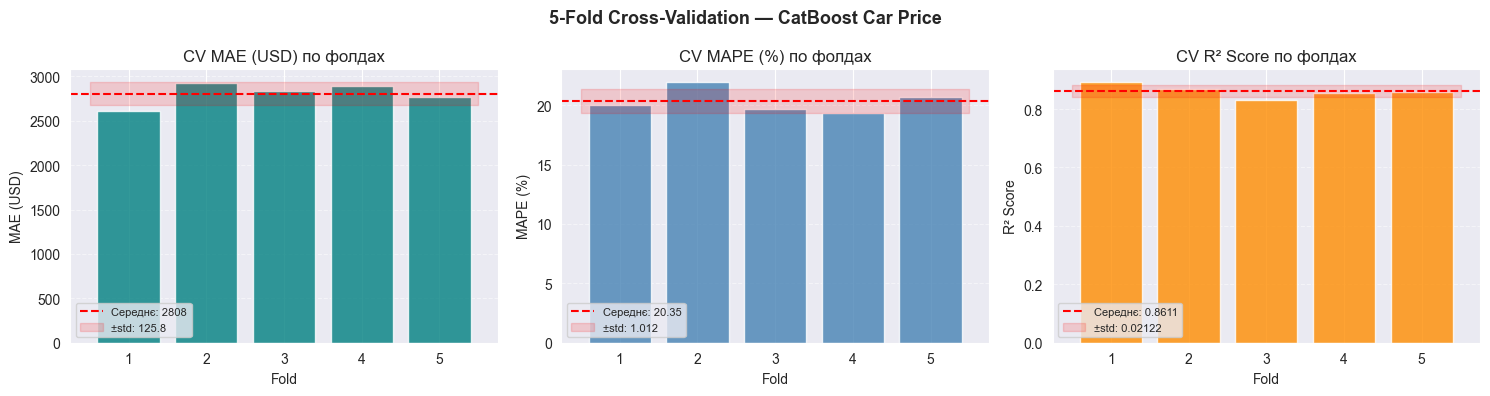

In [36]:
# Візуалізація результатів CV
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('MAE',  'MAE (USD)',      'teal'),
    ('MAPE', 'MAPE (%)',       'steelblue'),
    ('R2',   'R² Score',       'darkorange'),
]

for ax, (col, label, color) in zip(axes, metrics):
    vals = cv_df[col]
    bars = ax.bar(cv_df['fold'], vals, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(vals.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Середнє: {vals.mean():.4g}')
    ax.fill_between(
        [0.5, N_FOLDS + 0.5],
        vals.mean() - vals.std(),
        vals.mean() + vals.std(),
        alpha=0.15, color='red', label=f'±std: {vals.std():.4g}'
    )
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.set_title(f'CV {label} по фолдах')
    ax.set_xticks(cv_df['fold'])
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'{N_FOLDS}-Fold Cross-Validation — CatBoost Car Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [37]:
# Фінальна модель на повному train датасеті
# Використовуємо середню оптимальну ітерацію з CV (без early stopping)
best_iters_mean = int(cv_df['best_iter'].mean())
print(f"Навчаємо фінальну модель на {len(X_train_full)} прикладах, iterations={best_iters_mean}...")

final_params = {**CATBOOST_PARAMS, 'iterations': best_iters_mean, 'early_stopping_rounds': None, 'verbose': 200}
model = CatBoostRegressor(**final_params)
model.fit(X_train_full, y_train_full, cat_features=cat_features)
print("Фінальну модель навчено!")


Навчаємо фінальну модель на 14276 прикладах, iterations=2993...
0:	learn: 0.6203369	total: 4.73ms	remaining: 14.1s
200:	learn: 0.2150234	total: 792ms	remaining: 11s
400:	learn: 0.1908857	total: 1.52s	remaining: 9.82s
600:	learn: 0.1763505	total: 2.29s	remaining: 9.12s
800:	learn: 0.1671780	total: 3.04s	remaining: 8.33s
1000:	learn: 0.1596785	total: 3.81s	remaining: 7.58s
1200:	learn: 0.1531019	total: 4.57s	remaining: 6.82s
1400:	learn: 0.1479507	total: 5.34s	remaining: 6.07s
1600:	learn: 0.1428717	total: 6.07s	remaining: 5.28s
1800:	learn: 0.1387357	total: 6.86s	remaining: 4.54s
2000:	learn: 0.1349226	total: 7.63s	remaining: 3.78s
2200:	learn: 0.1314339	total: 8.38s	remaining: 3.02s
2400:	learn: 0.1282333	total: 9.14s	remaining: 2.25s
2600:	learn: 0.1252596	total: 9.96s	remaining: 1.5s
2800:	learn: 0.1222651	total: 10.7s	remaining: 736ms
2992:	learn: 0.1199096	total: 11.5s	remaining: 0us
Фінальну модель навчено!


## Оцінка якості моделі

In [38]:
# Оцінка на hold-out тесті
y_pred_log   = model.predict(X_test)
y_pred       = np.expm1(y_pred_log)
y_test_real  = np.expm1(y_test)

mae  = mean_absolute_error(y_test_real, y_pred)
mape = mean_absolute_percentage_error(y_test_real, y_pred) * 100
r2   = r2_score(y_test_real, y_pred)

print(f"\n{'═'*45}")
print(f"  HOLD-OUT TEST RESULTS")
print(f"{'─'*45}")
print(f"  MAE   (середня похибка):  {mae:,.2f} USD")
print(f"  MAPE  (відносна похибка): {mape:.2f}%")
print(f"  R²    (детермінація):     {r2:.4f}")
print(f"  Median AE:                {np.median(np.abs(y_test_real.values - y_pred)):,.2f} USD")
print(f"{'═'*45}")
print(f"\nПорівняння CV vs Hold-out:")
print(f"  CV MAE = {cv_df['MAE'].mean():,.0f} USD  |  Test MAE = {mae:,.0f} USD  →  {'✓ консистентно' if abs(mae - cv_df['MAE'].mean()) / cv_df['MAE'].mean() < 0.1 else '⚠ розходження > 10%'}")



═════════════════════════════════════════════
  HOLD-OUT TEST RESULTS
─────────────────────────────────────────────
  MAE   (середня похибка):  3,130.82 USD
  MAPE  (відносна похибка): 20.97%
  R²    (детермінація):     0.8525
  Median AE:                1,302.93 USD
═════════════════════════════════════════════

Порівняння CV vs Hold-out:
  CV MAE = 2,808 USD  |  Test MAE = 3,131 USD  →  ⚠ розходження > 10%


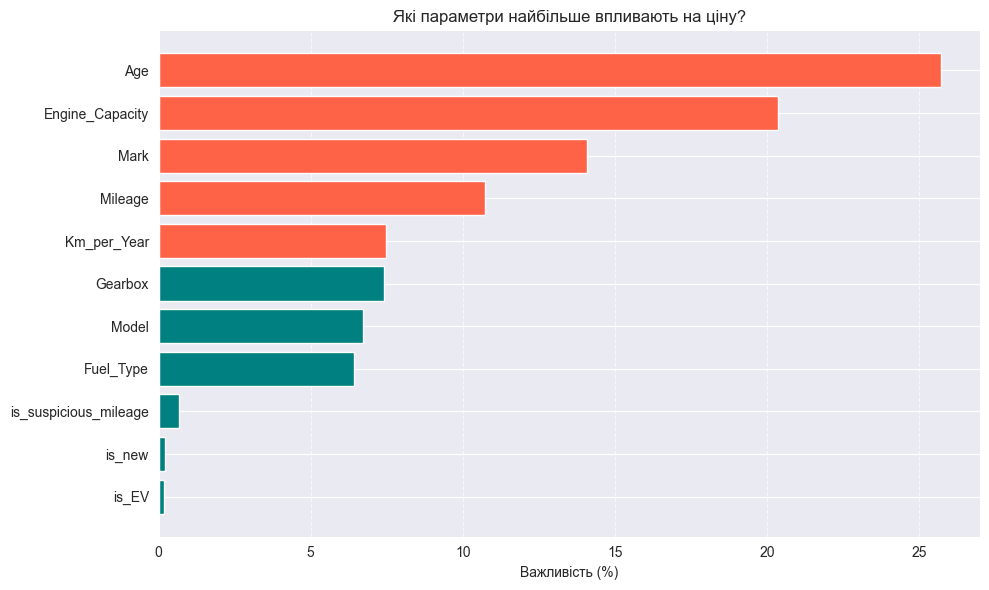

In [39]:
# FIX: Використовуємо правильний список ознак (включаючи is_new)
importance = model.get_feature_importance()
feat_imp = pd.Series(importance, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['tomato' if v > feat_imp.median() else 'teal' for v in feat_imp.values]
plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.xlabel('Важливість (%)')
plt.title('Які параметри найбільше впливають на ціну?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

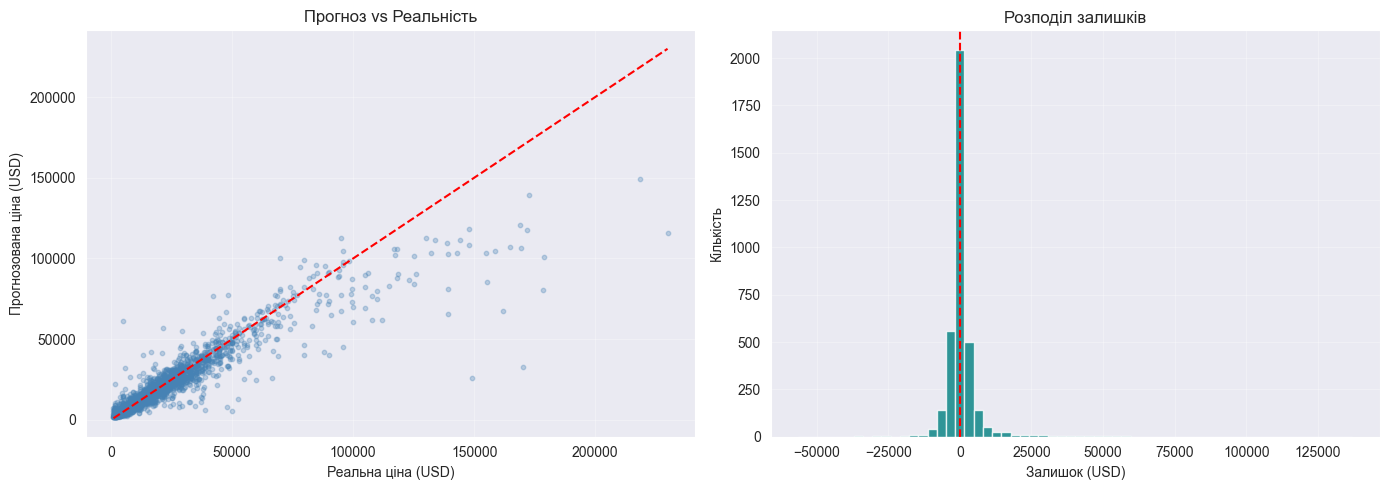

In [40]:
residuals = y_test_real.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_real, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--', linewidth=1.5
)
axes[0].set_xlabel('Реальна ціна (USD)')
axes[0].set_ylabel('Прогнозована ціна (USD)')
axes[0].set_title('Прогноз vs Реальність')
axes[0].grid(True, alpha=0.3)

# Розподіл залишків
axes[1].hist(residuals, bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Залишок (USD)')
axes[1].set_ylabel('Кількість')
axes[1].set_title('Розподіл залишків')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
import os

MODEL_DIR  = "../src/backend/models"
MODEL_PATH = os.path.join(MODEL_DIR, "catboost_car_price_model.cbm")

os.makedirs(MODEL_DIR, exist_ok=True)
model.save_model(MODEL_PATH)
print(f"Модель збережено у {MODEL_PATH}")

Модель збережено у ../src/backend/models\catboost_car_price_model.cbm
